In [5]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import ConfusionMatrixDisplay 

In [6]:
matches = pd.read_csv('../data/processed/features_v5.csv')

Accuracy: 0.4789473684210526
Log Loss: 1.0300046866773251
['A' 'D' 'H']
    EloDiff   PPGDiff  HomeAwayPPGDiff  HomeAwayGoalsDiff  \
A -0.003334 -0.196153         0.163314          -0.041891   
D  0.000348  0.042690        -0.057005           0.010163   
H  0.002986  0.153463        -0.106309           0.031728   

   HomeAwayGoalsAgainstDiff  HomeAwayShotsDiff  HomeAwayShotsOTDiff  
A                 -0.117154          -0.013005            -0.019563  
D                  0.050304          -0.008748            -0.026095  
H                  0.066850           0.021753             0.045658  


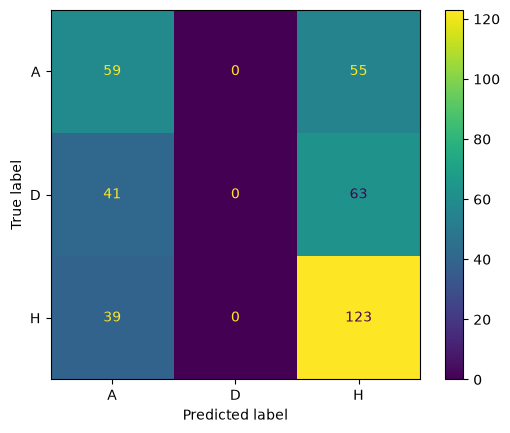

In [7]:
features_venue = [
    "EloDiff",
    "PPGDiff",
    "HomeAwayPPGDiff",
    "HomeAwayGoalsDiff",
    "HomeAwayGoalsAgainstDiff",
    "HomeAwayShotsDiff",
    "HomeAwayShotsOTDiff"
]

train = matches[matches['Season'] != '25-26']
test = matches[matches['Season'] == '25-26']

X_train = train[features_venue]
y_train = train['FTR']

X_test = test[features_venue]
y_test = test['FTR']

model_venue = LogisticRegression(
    max_iter=1000
)

model_venue.fit(X_train, y_train)

preds = model_venue.predict(X_test)
probs = model_venue.predict_proba(X_test)

accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)
print("Log Loss:", log_loss(y_test, probs))

print(model_venue.classes_)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds
)

importance = pd.DataFrame(
    model_venue.coef_,
    columns=features_venue,
    index=model_venue.classes_
)

print(importance)

In [8]:
features_overall = [
    "EloDiff",
    "PPGDiff",
    "GoalDiffLast5",
    "GoalAgainstDiffLast5",
    "ShotDiffLast5",
    "ShotOTDiffLast5"
]

train = matches[matches['Season'] != '25-26']
test = matches[matches['Season'] == '25-26']

X_train = train[features_overall]
y_train = train['FTR']

X_test = test[features_overall]
y_test = test['FTR']

model_overall = LogisticRegression(
    max_iter=1000
)

model_overall.fit(X_train, y_train)

preds = model_overall.predict(X_test)
probs = model_overall.predict_proba(X_test)

accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)
print("Log Loss:", log_loss(y_test, probs))

importance = pd.DataFrame(
    model_overall.coef_,
    columns=features_overall,
    index=model_overall.classes_
)

print(importance)

Accuracy: 0.48947368421052634
Log Loss: 1.0321935819545003
    EloDiff   PPGDiff  GoalDiffLast5  GoalAgainstDiffLast5  ShotDiffLast5  \
A -0.003264 -0.134510      -0.015547             -0.045686      -0.012634   
D  0.000350  0.038165       0.057846             -0.054846      -0.004676   
H  0.002914  0.096346      -0.042299              0.100532       0.017309   

   ShotOTDiffLast5  
A        -0.010067  
D        -0.049839  
H         0.059905  


Accuracy: 0.47368421052631576
Log Loss: 1.0317099172506148
    EloDiff   PPGDiff  GoalDiffLast5  GoalAgainstDiffLast5  ShotDiffLast5  \
A -0.003307 -0.183602      -0.028245             -0.013571      -0.006854   
D  0.000347  0.060573       0.083909             -0.095142      -0.001810   
H  0.002961  0.123030      -0.055664              0.108712       0.008664   

   ShotOTDiffLast5  HomeAwayPPGDiff  HomeAwayGoalsDiff  \
A        -0.006034         0.158388          -0.032594   
D        -0.024842        -0.055822          -0.028088   
H         0.030876        -0.102566           0.060682   

   HomeAwayGoalsAgainstDiff  HomeAwayShotsDiff  HomeAwayShotsOTDiff  
A                 -0.111833          -0.006854            -0.006034  
D                  0.090113          -0.001810            -0.024842  
H                  0.021721           0.008664             0.030876  


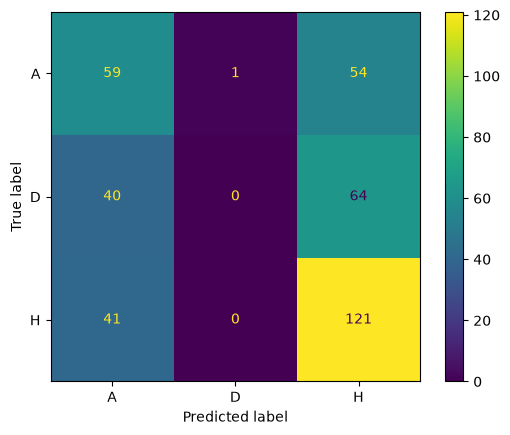

In [9]:
features_combined = [
    "EloDiff",
    "PPGDiff",

    # Overall last 5
    "GoalDiffLast5",
    "GoalAgainstDiffLast5",
    "ShotDiffLast5",
    "ShotOTDiffLast5",

    # Venue-specific last 5
    "HomeAwayPPGDiff",
    "HomeAwayGoalsDiff",
    "HomeAwayGoalsAgainstDiff",
    "HomeAwayShotsDiff",
    "HomeAwayShotsOTDiff"
]

train = matches[matches['Season'] != '25-26']
test = matches[matches['Season'] == '25-26']

X_train = train[features_combined]
y_train = train['FTR']

X_test = test[features_combined]
y_test = test['FTR']

model_combined = LogisticRegression(
    max_iter=1000
)

model_combined.fit(X_train, y_train)

preds = model_combined.predict(X_test)
probs = model_combined.predict_proba(X_test)

accuracy = accuracy_score(y_test, preds)
loss = log_loss(y_test, probs)

print("Accuracy:", accuracy)
print("Log Loss:", loss)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds
)

importance = pd.DataFrame(
    model_combined.coef_,
    columns=features_combined,
    index=model_combined.classes_
)

print(importance)

In [10]:
print(
    matches[
        [
            'ShotDiffLast5',
            'HomeAwayShotsDiff',
            'ShotOTDiffLast5',
            'HomeAwayShotsOTDiff'
        ]
    ].corr()
)

                     ShotDiffLast5  HomeAwayShotsDiff  ShotOTDiffLast5  \
ShotDiffLast5             1.000000           1.000000         0.788248   
HomeAwayShotsDiff         1.000000           1.000000         0.788248   
ShotOTDiffLast5           0.788248           0.788248         1.000000   
HomeAwayShotsOTDiff       0.788248           0.788248         1.000000   

                     HomeAwayShotsOTDiff  
ShotDiffLast5                   0.788248  
HomeAwayShotsDiff               0.788248  
ShotOTDiffLast5                 1.000000  
HomeAwayShotsOTDiff             1.000000  
